In [20]:
# Build main diff-in-diff analysis data

import os
import pandas as pd
import numpy as np
import dotenv

import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

dotenv.load_dotenv(dotenv.find_dotenv())

ROOT_PATH = os.getenv("ROOT_PATH")
MY_DATA_PATH = os.getenv("MY_DATA_PATH")
RAW_DATA_PATH = os.getenv("RAW_DATA_PATH")

OUTPUT_FILEPATH = os.path.join(MY_DATA_PATH, "processed_data/tax_analysis_panel.parquet")


In [21]:
# Load data

regs_df = pd.read_csv(os.path.join(RAW_DATA_PATH, "sales-analysis-redfin/data/best_treatment_dates_2026-07.csv"))
fisc_df = pd.read_excel(os.path.join(RAW_DATA_PATH, "lincoln-institute/FiSC-Full-Dataset-2023-Update.xlsx"), sheet_name="Data")
zhvi_df = pd.read_csv(os.path.join(RAW_DATA_PATH, "zhvi/City_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv"))
alfin_df = pd.read_parquet(os.path.join(MY_DATA_PATH, "processed_data/alfin_panel.parquet"))

zhvi_xwalk = pd.read_csv(os.path.join(MY_DATA_PATH, "raw_data/zhvi_xwalk.csv"))
fisc_xwalk = pd.read_csv(os.path.join(MY_DATA_PATH, "raw_data/fisc_xwalk.csv"))


In [22]:
# Reshape zhvi data long by year

id_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType',
           'StateName', 'State', 'Metro', 'CountyName']

zhvi_long = zhvi_df.melt(
    id_vars=id_cols,
    var_name = 'date',
    value_name = 'ZHVI'
)

zhvi_long['date'] = pd.to_datetime(zhvi_long['date'])
zhvi_long['year'] = zhvi_long['date'].dt.year

zhvi_long = zhvi_long.groupby(id_cols + ['year']).agg({'ZHVI': 'mean'}).reset_index()


In [23]:
# Merging the data

df = regs_df.merge(fisc_xwalk, on=['city', 'state'], how='left')
df = df.merge(zhvi_xwalk, on=['city', 'state'], how='left')

df = df.merge(alfin_df, on=['city', 'state'], how='left')
df = df.merge(fisc_df.rename(columns={'city_name': 'fisc_city'}), on=['fisc_city', 'year'], how='left')
df = df.merge(zhvi_long[['RegionID', 'year', 'ZHVI']], on=['RegionID', 'year'], how='left')


In [24]:
assert df[['city', 'state', 'year']].duplicated().sum() == 0
n_city = len(df.groupby(['city', 'state']))
n_year = len(df['year'].unique())
assert len(df) == n_city * n_year

In [25]:
# clean dates

df['best_enforcement'] = pd.to_datetime(df['best_enforcement'], errors='coerce')
df['best_passage'] = pd.to_datetime(df['best_passage'], errors='coerce')

df['enforcement_year'] = df['best_enforcement'].dt.year
df['passage_year'] = df['best_passage'].dt.year

df['years_from_enforcement'] = (df['year'] - df['enforcement_year'])
df['years_from_passage'] = (df['year'] - df['passage_year'])


In [26]:
# change enforcement and passage year to 0 for cities without enforcement/passage dates
# (standard convention for CSDID package in R)

df.loc[df['best_enforcement'].isna(), 'enforcement_year'] = 0
df.loc[df['best_passage'].isna(), 'passage_year'] = 0

df['enforcement_year'] = df['enforcement_year'].astype(int)
df['passage_year'] = df['passage_year'].astype(int)


In [27]:
# make a city_id integer (also required for CSDID package)

df['city_id'] = df['city'].astype('category').cat.codes

In [28]:
# output dataframe for analysis

df.to_parquet(OUTPUT_FILEPATH)

df['year'].value_counts()

year
2007    50
2008    50
2009    50
2010    50
2011    50
2012    50
2013    50
2014    50
2015    50
2016    50
2017    50
2018    50
2019    50
2020    50
2021    50
2022    50
2023    50
Name: count, dtype: int64

In [35]:
df[['city', 'state', 'year', 'A89', 'chg_other_city', 'city_population']]

,city,state,year,A89,chg_other_city,city_population
0,Albuquerque,NM,2007,26703.0,76.24,514723.0
1,Albuquerque,NM,2008,48557.0,131.12,524090.0
2,Albuquerque,NM,2009,49632.0,132.64,531451.0
3,Albuquerque,NM,2010,36176.0,93.75,539215.0
4,Albuquerque,NM,2011,35703.0,88.46,546747.0
...,...,...,...,...,...,...
845,Wichita,KS,2019,17705.0,54.30,389527.0
846,Wichita,KS,2020,20907.0,63.09,390335.0
847,Wichita,KS,2021,21303.0,61.15,391731.0
848,Wichita,KS,2022,23896.0,62.73,396708.0


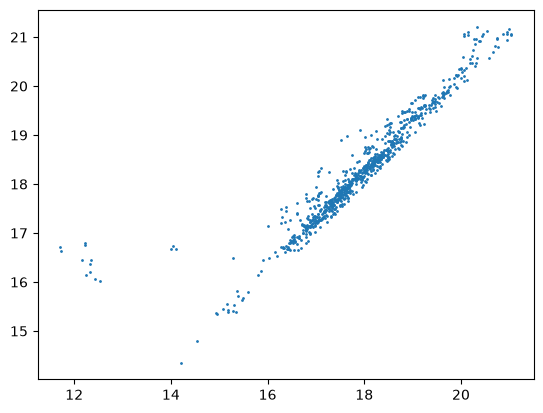

In [48]:
from matplotlib import pyplot as plt

plt.scatter(np.log1p(df['A89']*1000), np.log1p(df['chg_other_city']*df['city_population']), s=1)

In [53]:
df['chg_other_city_tot_k'] = df['chg_other_city']*df['city_population']/1000

weird = np.abs(np.log1p(df['A89']) - np.log1p(df['chg_other_city_tot_k'])) > 2

df.loc[weird, ['city', 'state', 'year', 'A03', 'A89', 'chg_other_city_tot_k']]

,city,state,year,A03,A89,chg_other_city_tot_k
125,Charlotte,NC,2013,6401.0,279.0,9104.16562
126,Charlotte,NC,2014,6606.0,249.0,9397.95888
127,Charlotte,NC,2015,7253.0,208.0,10219.61875
128,Charlotte,NC,2016,8184.0,225.0,12906.33740
129,Charlotte,NC,2017,8595.0,227.0,10963.41711
130,Charlotte,NC,2018,9743.0,232.0,14062.90610
131,Charlotte,NC,2019,10244.0,192.0,13794.67086
132,Charlotte,NC,2020,12078.0,124.0,16577.61576
133,Charlotte,NC,2021,14098.0,205.0,18808.31150
134,Charlotte,NC,2022,15103.0,203.0,19870.31932


In [55]:
(df['T29']==0).sum()

(df['T29'].isna()).sum()

np.int64(40)